# J01 — Phase solide et relations masse–volume

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 1 : relations masse–volume, granulométrie, loi de Stokes, triangle textural*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les données sont dans le dossier `data/`. Exécutez la cellule suivante pour importer les bibliothèques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
RHO_W = 1.0   # g/cm³

## Exercice 1 — Relations masse–volume  *(≈ 15 min)*

Le fichier `data/J01_echantillons.csv` contient 12 échantillons prélevés au cylindre ($V_t = 100$ cm³) dans deux
parcelles (`temoin` et `trafiquee`), à six profondeurs (tranches de 10 cm). Pour chacun : masse humide $M_t$,
masse sèche $M_s$ (105 °C, 24 h), masse volumique des solides $\rho_s$.

1. Calculer $\rho_b$, $w$, $\theta$, $n$, $e$, $S$ et $\theta_a$ pour chaque échantillon. Rappels :
   $\rho_b = M_s/V_t$, $w = M_w/M_s$, $\theta = w\,\rho_b/\rho_w$, $n = 1-\rho_b/\rho_s$, $e = n/(1-n)$, $S = \theta/n$, $\theta_a = n-\theta$.
2. Comparer les deux parcelles (moyennes par parcelle, boîtes à moustaches de $\rho_b$ et $\theta_a$).
   La parcelle trafiquée est-elle compactée ? Quels échantillons ont $\theta_a < 0{,}10$ ?
3. Calculer le stock d'eau (mm) du profil 0–60 cm de chaque parcelle, chaque échantillon représentant une tranche de 10 cm.

,id,parcelle,profondeur_cm,rho_b,w,theta,n,e,S,theta_a
0,TEM-1,temoin,0-10,1.296,0.162,0.210,0.502,1.006,0.419,0.292
1,TEM-2,temoin,10-20,1.341,0.202,0.271,0.484,0.939,0.560,0.213
2,TEM-3,temoin,20-30,1.401,0.208,0.291,0.471,0.892,0.617,0.180
3,TEM-4,temoin,30-40,1.361,0.222,0.302,0.486,0.947,0.621,0.184
4,TEM-5,temoin,40-50,1.437,0.237,0.341,0.458,0.844,0.745,0.117
5,TEM-6,temoin,50-60,1.467,0.231,0.339,0.446,0.806,0.759,0.107
6,TRA-1,trafiquee,0-10,1.508,0.178,0.269,0.420,0.724,0.640,0.151
7,TRA-2,trafiquee,10-20,1.625,0.159,0.259,0.375,0.600,0.691,0.116
8,TRA-3,trafiquee,20-30,1.577,0.185,0.292,0.405,0.680,0.721,0.113
9,TRA-4,trafiquee,30-40,1.647,0.177,0.292,0.378,0.609,0.771,0.086


           rho_b      n  theta  theta_a
parcelle                               
temoin     1.384  0.475  0.292    0.182
trafiquee  1.610  0.388  0.290    0.098


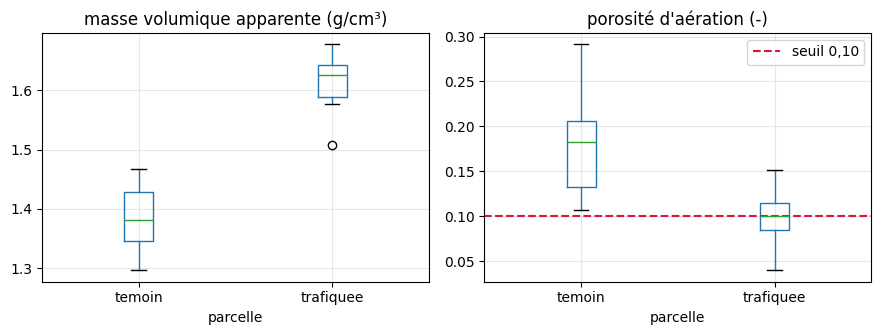

Échantillons avec theta_a < 0,10 : ['TRA-4', 'TRA-5', 'TRA-6']
Stock d'eau 0-60 cm (mm) :
parcelle
temoin       175.4
trafiquee    174.1
Name: theta, dtype: float64


In [2]:
df = pd.read_csv("data/J01_echantillons.csv")

# 1. relations masse-volume
df["M_w"]     = df["M_t_g"] - df["M_s_g"]
df["rho_b"]   = df["M_s_g"] / df["V_t_cm3"]
df["w"]       = df["M_w"] / df["M_s_g"]
df["theta"]   = df["w"] * df["rho_b"] / RHO_W
df["n"]       = 1 - df["rho_b"] / df["rho_s_gcm3"]
df["e"]       = df["n"] / (1 - df["n"])
df["S"]       = df["theta"] / df["n"]
df["theta_a"] = df["n"] - df["theta"]
cols = ["id", "parcelle", "profondeur_cm", "rho_b", "w", "theta", "n", "e", "S", "theta_a"]
display(df[cols].round(3))

# 2. comparaison des parcelles
print(df.groupby("parcelle")[["rho_b", "n", "theta", "theta_a"]].mean().round(3))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
df.boxplot(column="rho_b", by="parcelle", ax=ax[0]); ax[0].set_title("masse volumique apparente (g/cm³)")
df.boxplot(column="theta_a", by="parcelle", ax=ax[1]); ax[1].set_title("porosité d'aération (-)")
ax[1].axhline(0.10, color="crimson", ls="--", label="seuil 0,10"); ax[1].legend()
fig.suptitle("")
plt.tight_layout(); plt.show()
print("Échantillons avec theta_a < 0,10 :", df.loc[df["theta_a"] < 0.10, "id"].tolist())

# 3. stock d'eau 0-60 cm (mm) : chaque échantillon représente 100 mm de sol
stock = df.groupby("parcelle")["theta"].sum() * 100
print("Stock d'eau 0-60 cm (mm) :"); print(stock.round(1))

**Commentaire (instructeur).** La parcelle trafiquée a une $\rho_b$ supérieure d'environ 0,2 g/cm³ et une porosité inférieure de ~0,08 ; à teneur en eau
comparable, sa porosité d'aération tombe sous le seuil de 0,10 pour plusieurs échantillons : c'est le diagnostic classique de la compaction.
Le stock d'eau est exprimé en mm pour être comparé directement aux pluies et à l'ET (voir Jour 8).

## Exercice 2 — Courbes granulométriques  *(≈ 15 min)*

`data/J01_granulometrie.csv` donne le pourcentage passant (masse cumulée) en fonction du diamètre pour trois sols A, B, C.

1. Tracer les trois courbes cumulées (axe des diamètres en échelle logarithmique).
2. Écrire une fonction `D_x(d, p, x)` qui retourne, par **interpolation linéaire en $\log d$**, le diamètre pour lequel $x$ % de
   la masse est plus fine. Calculer $D_{10}$, $D_{30}$, $D_{50}$, $D_{60}$, puis $C_u = D_{60}/D_{10}$ et $C_c = D_{30}^2/(D_{10} D_{60})$.
3. Calculer les fractions argile/limon/sable selon l'USDA (2 µm, 50 µm) et selon ISO (2 µm, 63 µm).
4. Ajuster une loi log-normale $F(d) = \tfrac12[1+\mathrm{erf}((\ln d - \ln d_g)/(\sqrt2 \ln\sigma_g))]$ sur le sol A
   (`scipy.optimize.curve_fit`) et superposer la courbe ajustée.

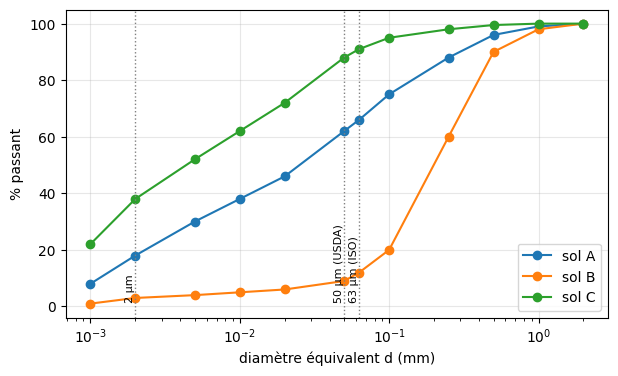

,D10,D30,D50,D60,Cu,Cc
sol,,,,,,
A,0.0011,0.0050,0.0251,0.0446,38.8170,0.4881
B,0.0540,0.1257,0.1988,0.2500,4.6293,1.1711
C,0.0010,0.0014,0.0044,0.0087,8.7055,0.2297


Fractions USDA (%) :


,argile,limon,sable
A,18.0,44.0,38.0
B,3.0,6.0,91.0
C,38.0,50.0,12.0


Fractions ISO (%) :


,argile,limon,sable
A,18.0,48.0,34.0
B,3.0,9.0,88.0
C,38.0,53.0,9.0


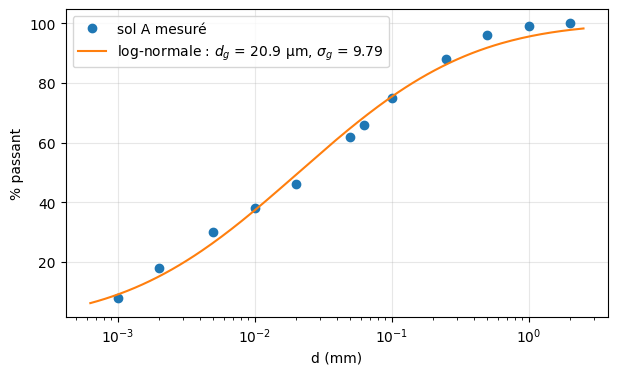

RMSE de l'ajustement : 2.67 %


In [3]:
g = pd.read_csv("data/J01_granulometrie.csv")
d = g["d_mm"].to_numpy()
sols = {"A": g["sol_A_pct"].to_numpy(), "B": g["sol_B_pct"].to_numpy(), "C": g["sol_C_pct"].to_numpy()}

# 1. tracé
fig, ax = plt.subplots()
for k, p in sols.items():
    ax.semilogx(d, p, "o-", label=f"sol {k}")
for D, lab in [(0.002, "2 µm"), (0.05, "50 µm (USDA)"), (0.063, "63 µm (ISO)")]:
    ax.axvline(D, color="gray", ls=":", lw=1); ax.text(D, 2, lab, rotation=90, fontsize=8, ha="right")
ax.set_xlabel("diamètre équivalent d (mm)"); ax.set_ylabel("% passant"); ax.legend(); plt.show()

# 2. diamètres caractéristiques
def D_x(d, p, x):
    """Diamètre (mm) tel que x % de la masse est plus fine (interpolation linéaire en log10 d)."""
    return 10 ** np.interp(x, p, np.log10(d))

res = []
for k, p in sols.items():
    D10, D30, D50, D60 = (D_x(d, p, x) for x in (10, 30, 50, 60))
    res.append(dict(sol=k, D10=D10, D30=D30, D50=D50, D60=D60, Cu=D60 / D10, Cc=D30**2 / (D10 * D60)))
res = pd.DataFrame(res).set_index("sol")
display(res.round(4))

# 3. fractions texturales
def fractions(d, p, lim_sable=0.05):
    argile = np.interp(np.log10(0.002), np.log10(d), p)
    limon = np.interp(np.log10(lim_sable), np.log10(d), p) - argile
    sable = 100 - argile - limon
    return argile, limon, sable

frac = pd.DataFrame({k: dict(zip(["argile", "limon", "sable"], fractions(d, p))) for k, p in sols.items()}).T
frac_iso = pd.DataFrame({k: dict(zip(["argile", "limon", "sable"], fractions(d, p, 0.063))) for k, p in sols.items()}).T
print("Fractions USDA (%) :"); display(frac.round(1))
print("Fractions ISO (%) :"); display(frac_iso.round(1))

# 4. loi log-normale sur le sol A
def F_lognormale(d, dg, sg):
    return 50 * (1 + special.erf((np.log(d) - np.log(dg)) / (np.sqrt(2) * np.log(sg))))

popt, _ = optimize.curve_fit(F_lognormale, d, sols["A"], p0=[0.02, 5])
dg, sg = popt
dd = np.logspace(-3.2, 0.4, 200)
fig, ax = plt.subplots()
ax.semilogx(d, sols["A"], "o", label="sol A mesuré")
ax.semilogx(dd, F_lognormale(dd, *popt), "-", label=f"log-normale : $d_g$ = {dg*1000:.1f} µm, $\\sigma_g$ = {sg:.2f}")
ax.set_xlabel("d (mm)"); ax.set_ylabel("% passant"); ax.legend(); plt.show()
rmse = np.sqrt(np.mean((F_lognormale(d, *popt) - sols["A"])**2))
print(f"RMSE de l'ajustement : {rmse:.2f} %")

**Commentaire (instructeur).** Le sol B (sable) est uniforme ($C_u \approx 2$–3), le sol A est bien gradué. Passer de la limite USDA (50 µm) à la limite ISO (63 µm)
déplace quelques pour cent du sable vers le limon : la classe texturale peut changer, d'où l'importance de préciser le système.
L'ajustement log-normal est raisonnable pour A mais une distribution bimodale ferait mieux pour un sol à deux populations de grains.

## Exercice 3 — Loi de Stokes et sédimentation  *(≈ 10 min)*

1. Écrire `viscosite(T)` (Pa·s) par interpolation dans la table : 5 °C : 1,519 ; 10 °C : 1,307 ; 15 °C : 1,139 ;
   20 °C : 1,002 ; 25 °C : 0,890 ; 30 °C : 0,798 (mPa·s).
2. Écrire `stokes(d, T)` qui retourne la vitesse de chute (m/s) d'une particule de diamètre $d$ (m) à la température $T$,
   avec $\rho_s = 2650$ et $\rho_w = 998$ kg/m³ : $v = g(\rho_s-\rho_w)d^2/(18\mu)$.
3. Produire la table des temps (h:min:s) nécessaires pour qu'une particule de 50, 20, 5 et 2 µm parcoure 10 cm, à 15, 20 et 25 °C.
4. Déterminer le diamètre pour lequel $Re = \rho_w v d/\mu = 1$ à 20 °C (limite de validité) avec `scipy.optimize.brentq`.

In [4]:
T_tab  = np.array([5, 10, 15, 20, 25, 30])
mu_tab = np.array([1.519, 1.307, 1.139, 1.002, 0.890, 0.798]) * 1e-3   # Pa s
RHO_S, RHO_WATER, G = 2650.0, 998.0, 9.81

def viscosite(T):
    """Viscosité dynamique de l'eau (Pa s) par interpolation linéaire."""
    return np.interp(T, T_tab, mu_tab)

def stokes(d, T):
    """Vitesse de chute (m/s) d'une sphère de diamètre d (m) à T (°C)."""
    return G * (RHO_S - RHO_WATER) * d**2 / (18 * viscosite(T))

def hms(t):
    t = int(round(t)); return f"{t//3600:d} h {(t%3600)//60:02d} min {t%60:02d} s"

z = 0.10
rows = []
for dm in [50, 20, 5, 2]:
    row = {"d (µm)": dm}
    for T in [15, 20, 25]:
        row[f"{T} °C"] = hms(z / stokes(dm * 1e-6, T))
    rows.append(row)
display(pd.DataFrame(rows).set_index("d (µm)"))

# 4. diamètre limite Re = 1 à 20 °C
Re = lambda d, T=20: RHO_WATER * stokes(d, T) * d / viscosite(T)
d_lim = optimize.brentq(lambda d: Re(d) - 1, 1e-6, 1e-3)
print(f"Re = 1 pour d ≈ {d_lim*1e6:.0f} µm : au-delà, la loi de Stokes surestime la vitesse (tamisage nécessaire).")

,15 °C,20 °C,25 °C
d (µm),,,
50,0 h 00 min 51 s,0 h 00 min 45 s,0 h 00 min 40 s
20,0 h 05 min 16 s,0 h 04 min 38 s,0 h 04 min 07 s
5,1 h 24 min 20 s,1 h 14 min 12 s,1 h 05 min 54 s
2,8 h 47 min 07 s,7 h 43 min 43 s,6 h 51 min 53 s


Re = 1 pour d ≈ 104 µm : au-delà, la loi de Stokes surestime la vitesse (tamisage nécessaire).


**Commentaire (instructeur).** La viscosité varie de ~2,5 %/°C : une erreur de 5 °C sur la température change les temps de prélèvement de ~13 %.
Le diamètre limite (~100 µm) justifie de tamiser les sables et de ne sédimenter que les limons et argiles.

## Exercice 4 — Triangle textural  *(≈ 15 min)*

1. Programmer `classe_usda(sable, argile)` qui retourne la classe texturale USDA (12 classes) à partir des règles du triangle
   (le limon vaut $100 - $ sable $-$ argile). Rappels des règles principales : argile ≥ 40 → *argile* (sable ≤ 45, limon < 40),
   *argile limoneuse* (limon ≥ 40) ou *argile sableuse* (argile ≥ 35, sable > 45) ; 27 ≤ argile < 40 → *loam argileux*
   (20 < sable ≤ 45) ou *loam limono-argileux* (sable ≤ 20) ; 20 ≤ argile < 35, sable > 45, limon < 28 → *loam sablo-argileux* ;
   7 ≤ argile < 27, 28 ≤ limon < 50, sable ≤ 52 → *loam* ; limon ≥ 50 → *loam limoneux* (12 ≤ argile < 27, ou argile < 12 et limon < 80)
   ou *limon* (limon ≥ 80, argile < 12) ; sinon : *sable* si limon + 1,5 argile < 15, *sable loameux* si limon + 2 argile < 30,
   *loam sableux* autrement.
2. Écrire `tern(sable, argile)` qui convertit une composition en coordonnées cartésiennes du triangle
   ($x = 100 - $ sable $-$ argile$/2$, $y = $ argile $\cdot\sqrt3/2$) et tracer le triangle (contour + graduations).
3. Placer les sols A, B, C (exercice 2, fractions USDA) et les 12 échantillons de l'exercice 1 ; annoter la classe.

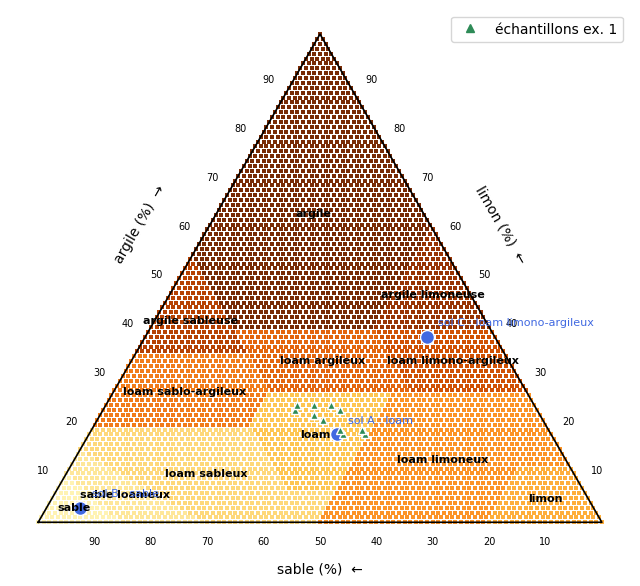

classe_USDA
loam    12
Name: count, dtype: int64


In [5]:
def classe_usda(sable, argile):
    limon = 100 - sable - argile
    if argile >= 40 and sable <= 45 and limon < 40:   return "argile"
    if argile >= 40 and limon >= 40:                  return "argile limoneuse"
    if argile >= 35 and sable > 45:                   return "argile sableuse"
    if 27 <= argile < 40 and 20 < sable <= 45:        return "loam argileux"
    if 27 <= argile < 40 and sable <= 20:             return "loam limono-argileux"
    if 20 <= argile < 35 and sable > 45 and limon < 28: return "loam sablo-argileux"
    if 7 <= argile < 27 and 28 <= limon < 50 and sable <= 52: return "loam"
    if (limon >= 50 and 12 <= argile < 27) or (50 <= limon < 80 and argile < 12): return "loam limoneux"
    if limon >= 80 and argile < 12:                   return "limon"
    if limon + 1.5 * argile < 15:                     return "sable"
    if limon + 2 * argile < 30:                       return "sable loameux"
    return "loam sableux"

def tern(sable, argile):
    return 100 - sable - argile / 2, argile * np.sqrt(3) / 2

# fond coloré : classification d'une grille de compositions
classes = ["sable", "sable loameux", "loam sableux", "loam", "limon", "loam limoneux", "loam sablo-argileux",
           "loam argileux", "loam limono-argileux", "argile sableuse", "argile limoneuse", "argile"]
couleurs = dict(zip(classes, plt.cm.YlOrBr(np.linspace(0.15, 0.95, 12))))
fig, ax = plt.subplots(figsize=(8, 7))
pts = {c: [] for c in classes}
for s in np.arange(0, 100.1, 1):
    for a in np.arange(0, 100.1 - s, 1):
        pts[classe_usda(s, a)].append(tern(s, a))
for c, P in pts.items():
    P = np.array(P)
    ax.scatter(P[:, 0], P[:, 1], s=9, marker="s", color=couleurs[c], linewidths=0)
    ax.text(*P.mean(axis=0), c, ha="center", va="center", fontsize=8, fontweight="bold")
tri = np.array([tern(100, 0), tern(0, 0), tern(0, 100), tern(100, 0)])
ax.plot(tri[:, 0], tri[:, 1], "k-", lw=1.2)
for k in range(10, 100, 10):
    ax.text(*np.add(tern(k, 0), (0, -4)), str(k), ha="center", fontsize=7)
    ax.text(*np.add(tern(0, k), (3, 0)), str(k), ha="left", fontsize=7)
    ax.text(*np.add(tern(100 - k, k), (-3, 0)), str(k), ha="right", fontsize=7)
ax.text(50, -9, "sable (%)  ←", ha="center"); ax.text(82, 46, "limon (%)  ←", rotation=-60, ha="center")
ax.text(18, 46, "argile (%)  →", rotation=60, ha="center")

# sols A, B, C (fractions USDA de l'exercice 2) et échantillons de l'exercice 1
for k in frac.index:
    s, a = frac.loc[k, "sable"], frac.loc[k, "argile"]
    ax.plot(*tern(s, a), "o", ms=10, color="royalblue", mec="white")
    ax.annotate(f"sol {k} : {classe_usda(s, a)}", tern(s, a), (8, 8), textcoords="offset points", fontsize=8, color="royalblue")
for _, r in df.iterrows():
    ax.plot(*tern(r["sable_pct"], r["argile_pct"]), "^", ms=6, color="seagreen", mec="white")
ax.plot([], [], "^", color="seagreen", label="échantillons ex. 1"); ax.legend(loc="upper right")
ax.set_aspect("equal"); ax.axis("off"); plt.show()

df["classe_USDA"] = [classe_usda(s, a) for s, a in zip(df["sable_pct"], df["argile_pct"])]
print(df["classe_USDA"].value_counts())

**Commentaire (instructeur).** Les 12 échantillons (38 % sable, 21 % argile) sont tous des loams ; le sol C (argile ~38 %) est un loam limono-argileux et le sol B un sable.
Le tracé « par grille » évite d'avoir à coder les polygones des classes : on classe des milliers de points et on colore.

## Exercice 5 — Bonus — analyse dimensionnelle avec sympy  *(≈ facultatif)*

Avec `sympy`, résoudre le système d'exposants du théorème de Buckingham pour $\Pi_1 = v\,d^{a}\Delta\rho^{b}\mu^{c}$ et
$\Pi_2 = g\,d^{a}\Delta\rho^{b}\mu^{c}$ (dimensions M, L, T), puis vérifier numériquement, pour $d$ de 1 à 60 µm,
que $\Pi_1/\Pi_2 = 1/18$ dans le régime de Stokes.

In [6]:
import sympy as sp
a, b, c = sp.symbols("a b c")
# exposants (M, L, T) : d -> (0,1,0) ; Δρ -> (1,-3,0) ; μ -> (1,-1,-1)
def pi_exposants(M0, L0, T0):
    eqs = [sp.Eq(M0 + b + c, 0), sp.Eq(L0 + a - 3*b - c, 0), sp.Eq(T0 - c, 0)]
    return sp.solve(eqs, (a, b, c))
print("Π1 (v = L T^-1) :", pi_exposants(0, 1, -1))
print("Π2 (g = L T^-2) :", pi_exposants(0, 1, -2))

dd = np.linspace(1, 60, 6) * 1e-6
mu, drho = viscosite(20), RHO_S - RHO_WATER
v = stokes(dd, 20)
Pi1 = v * dd * drho / mu
Pi2 = G * dd**3 * drho**2 / mu**2
print("Π1/Π2 =", np.round(Pi1 / Pi2, 5), " (1/18 =", round(1/18, 5), ")")

Π1 (v = L T^-1) : {a: 1, b: 1, c: -1}
Π2 (g = L T^-2) : {a: 3, b: 2, c: -2}
Π1/Π2 = [0.05556 0.05556 0.05556 0.05556 0.05556 0.05556]  (1/18 = 0.05556 )


**Commentaire (instructeur).** Les exposants (1, 1, −1) et (3, 2, −2) sont retrouvés ; le rapport Π₁/Π₂ = 1/18 est exact par construction de la loi de Stokes.

## Pour aller plus loin

* Refaire l'exercice 2 avec une distribution bimodale (somme de deux log-normales) pour le sol C.
* Estimer la surface spécifique des trois sols à partir de leur courbe granulométrique ($S_s = \sum_i f_i\, 6/(\rho_s d_i)$).
* Comparer vos fonctions à celles du paquet `soiltexture` (R) ou `pyrolite` (Python).